In [32]:
# %%
import os
import random
from tqdm.autonotebook import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from enum import Enum
import cv2
from tensorflow.keras import backend as K  # Keras backend (included in TensorFlow)
import gc
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import csv
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    BatchNormalization,
    Activation,
    SpatialDropout2D,
    AvgPool2D,
    MaxPool2D,
    Dropout,
    GlobalAveragePooling2D,
    GlobalMaxPooling2D,
    Flatten,
    Dense,
)
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import (
    ResNet152V2,
    DenseNet121,
    DenseNet169,
    DenseNet201,
    VGG16,
    VGG19,
    ResNet50,
)
# Import numpy.dstack
from numpy import dstack

# Alternative for TensorFlow Addons
from sklearn.metrics import cohen_kappa_score, accuracy_score

In [33]:
# %%
seed = 3352024
os.environ["PYTHONHASHSEED"] = str(seed)
random.seed(seed)
tf.random.set_seed(seed)
np.random.seed(seed)

In [34]:
# %%
def load_path(path):
    """
    Load MURA dataset with corresponding labels and file paths
    """
    dataset = []
    for body in os.listdir(path):
        path_p = os.path.join(path, body)
        # print(os.listdir(path_p))
        for id_p in os.listdir(path_p):
            # print(id_p)
            path_id = os.path.join(path_p, id_p)
            # print(os.listdir(path_id))
            for lab in os.listdir(path_id):
                label = 1 if "positive" in lab else 0
                path_l = os.path.join(path_id, lab)
                for img in os.listdir(path_l):
                    img_path = os.path.join(path_l, img)
                    dataset.append(
                        {
                            "body_part": body,
                            "patient_id": id_p,
                            "label": label,
                            "img_path": img_path,
                        }
                    )
    return dataset


In [35]:
# %%
# Load the validation dataset
valid_path = os.path.join(os.path.join(os.getcwd(), "D://DDLP//MURA-v1.1//valid"))
dataset_valid = load_path(valid_path)
df_valid = pd.DataFrame(dataset_valid)


In [36]:
# %%
# CSV file paths for train and validation sets
valid_image_paths_csv = "D://DDLP//MURA-v1.1//valid_image_paths.csv"


In [37]:
# %%
# Function to load CSV file and return DataFrame
def load_csv(file_path):
    try:
        with open(file_path, mode="r", newline="", encoding="utf-8") as file:
            reader = csv.reader(file)
            header = next(reader)  # Assuming there's a header
            data = [row for row in reader]
        return pd.DataFrame(data, columns=["image_path"])
    except Exception as e:
        print(f"Error reading the CSV file: {e}")
        return pd.DataFrame()


In [38]:
# %%
# Load CSV data into DataFrames
valid_images_paths = load_csv(os.path.join(os.getcwd(), valid_image_paths_csv))


In [40]:
import os

# Function to check if all image paths are valid
def check_image_paths(df, base_path):
    for image_path in df["image_path"]:
        # Ensure no double valid folder in path, remove 'MURA-v1.1/valid/' from the start if present
        if image_path.startswith("MURA-v1.1/valid/"):
            image_path = image_path.replace("MURA-v1.1/valid/", "")
        
        # Create the full path by joining base_path and the cleaned image_path
        full_path = os.path.join(base_path, image_path)
        
        if not os.path.exists(full_path):
            print(f"File not found: {full_path}")

# Call the function with the valid path as base
check_image_paths(valid_images_paths, valid_path)


In [42]:
# %%
# Image display function
def load_and_show_image(image_path):
    image = cv2.imread(image_path)
    if image is not None:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        plt.imshow(image)
        plt.axis("off")
        plt.show()
    else:
        print(f"Unable to load image at {image_path}")


In [44]:
# %%
valid_images_paths["label"] = valid_images_paths["image_path"].apply(
    lambda x: "positive" if "positive" in x else "negative"
)
valid_images_paths["category"] = valid_images_paths["image_path"].apply(
    lambda x: x.split("/")[2]
)
valid_images_paths["dir"] = valid_images_paths["image_path"].apply(
    lambda x: x.split("/")[1]
)
valid_images_paths["patientId"] = valid_images_paths["image_path"].apply(
    lambda x: x.split("/")[3].replace("patient", "")
)
valid_images_paths["label_index"] = valid_images_paths["label"].map(
    {"positive": 1, "negative": 0}
)


In [45]:
# %%
# Image Preprocessing for model
def random_rotation_flip(image, size=256):
    if random.randint(0, 1):
        image = cv2.flip(image, 1)  # Horizontal flip

    if random.randint(0, 1):
        angle = random.randint(-30, 30)
        M = cv2.getRotationMatrix2D((size / 2, size / 2), angle, 1)
        image = cv2.warpAffine(image, M, (size, size))

    return image


In [46]:
# %%
# Function to load and preprocess images
def image_loader(paths, size=224):
    Images = []
    for path in tqdm(paths):
        try:
            if not os.path.exists(path):
                print(f"Warning: File does not exist at {path}. Skipping.")
                continue

            image = cv2.imread(path)
            # image = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
            if image is None:
                print(f"Warning: Unable to load image at {path}. Skipping.")
                continue

            image = cv2.resize(image, (size, size))
            image = random_rotation_flip(image, size)
            Images.append(np.asarray(image).astype("float32"))

        except Exception as e:
            print(f"Error processing image at {path}: {str(e)}")

    if len(Images) == 0:
        print("Error: No images were loaded. Please check your paths and files.")
        return None

    Images = np.array(Images)
    mean = np.mean(Images)
    std = np.std(Images)
    Images = (Images - mean) / std  # Standardize images

    return Images

In [62]:
# %%
# Y_train = train_images_paths["label_index"][:25000]
Y_test = valid_images_paths["label_index"][:2000]


In [63]:
# %%
X_test = image_loader(valid_images_paths["image_path"][:2000], size=256)


100%|██████████| 2000/2000 [00:07<00:00, 264.04it/s]


In [64]:
# %%
X_test.shape


(2000, 256, 256, 3)

In [65]:
# %%
# Setup ImageDataGenerator for augmentation
datagen = ImageDataGenerator(rescale=1.0 / 255)
# train_generator = datagen.flow_from_dataframe(
#     dataframe=train_images_paths,
#     x_col="image_path",
#     target_size=(256, 256),
#     batch_size=32,
#     class_mode=None,
#     shuffle=True,
#     dtype=tf.float32,
# )

In [66]:
#train_generator = datagen.flow(X_train, Y_train, batch_size=32)
valid_generator = datagen.flow(X_test, Y_test, batch_size=32)


In [67]:
valid_generator = datagen.flow(X_test, Y_test, batch_size=32)

In [68]:
# %%
# train_images_paths["label_index"] = train_images_paths.label
valid_images_paths["label_index"] = valid_images_paths.label


In [69]:
# %%
valid_images_paths["label_index"] = valid_images_paths["label_index"].map(
    {"positive": 1, "negative": 0}
)

In [70]:
# Print column names of valid_data_paths
print("Columns in valid_data_paths:", valid_images_paths.columns)


Columns in valid_data_paths: Index(['image_path', 'label', 'category', 'dir', 'patientId', 'label_index'], dtype='object')


In [71]:
# %%
im_size = 256


def random_rotation_flip(image, size=256):
    if random.randint(0, 1):
        image = cv2.flip(
            image, 1
        )  # 1-->horizontal flip, 0-->Vertical flip, -1-->Horizontal and vertical flip

    if random.randint(0, 1):
        angle = random.randint(-30, 30)
        M = cv2.getRotationMatrix2D((size / 2, size / 2), angle, 1)
        image = cv2.warpAffine(image, M, (size, size))

    return image


In [72]:
# %%
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import AUC, BinaryAccuracy


In [73]:
# %%
def metrics():
    return [
        AUC(name="auc"),
        BinaryAccuracy("accuracy"),
        # CohenKappa(name="kappa", num_classes=2)
    ]


In [74]:
# Import necessary libraries
from tensorflow.keras.models import load_model
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [75]:
# Load the saved model
loaded_model = load_model('D://DDLP//MURA_model.keras')
print("Model loaded successfully.")

Model loaded successfully.


d:\DDLP\Mura\Lib\site-packages\keras\src\saving\saving_lib.py:713: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 4 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [77]:
# # Evaluate the model on the validation set
# test_loss, test_acc = loaded_model.evaluate(valid_generator)
# print(f'Test Loss: {test_loss}')
# print(f'Test Accuracy: {test_acc}')

# Evaluate the model on the validation set
results = loaded_model.evaluate(valid_generator)

# Print all metrics returned by the evaluate method to inspect the number of values
print("Evaluation results:", results)

# Unpack the results based on the number of metrics used during model compilation
# Modify this part based on the actual metrics used
# Example for three metrics: loss, accuracy, and auc
test_loss = results[0]  # First value is always loss
test_acc = results[1]   # Second value is accuracy
test_auc = results[2]   # Third value is AUC (or any other metric you've added)

# Print the results
print(f'Test Loss: {test_loss}')
print(f'Test Accuracy: {test_acc}')
print(f'Test AUC: {test_auc}')


63/63 ━━━━━━━━━━━━━━━━━━━━ 216s 3s/step - accuracy: 0.5236 - auc: 0.5415 - loss: 0.6926
Evaluation results: [0.6944660544395447, 0.5324639081954956, 0.5130000114440918]
Test Loss: 0.6944660544395447
Test Accuracy: 0.5324639081954956
Test AUC: 0.5130000114440918


In [78]:
# Function to display an image
def load_and_show_image(image_path):
    image = cv2.imread(image_path)
    if image is not None:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        plt.imshow(image)
        plt.axis("off")
        plt.show()
    else:
        print(f"Unable to load image at {image_path}")

In [79]:
# Test predictions on some validation images
predictions = loaded_model.predict(X_test[:10])


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


Image 1: Predicted: negative, True label: positive


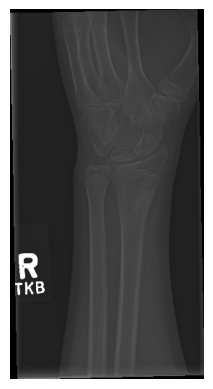

Image 2: Predicted: negative, True label: positive


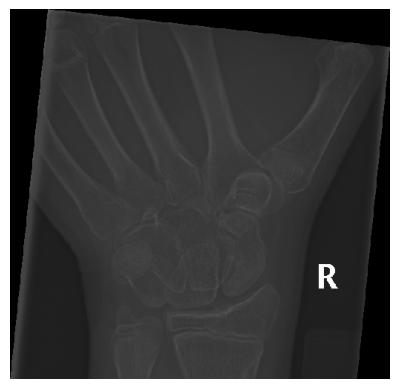

Image 3: Predicted: negative, True label: positive


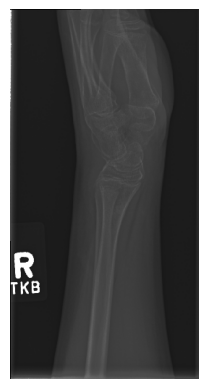

Image 4: Predicted: negative, True label: positive


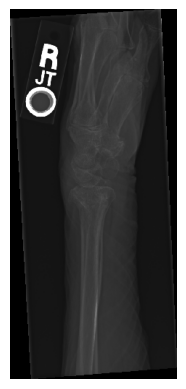

Image 5: Predicted: negative, True label: positive


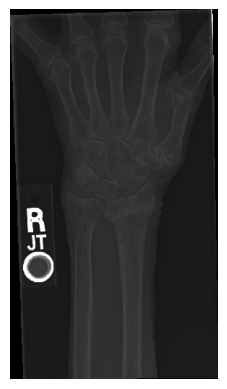

Image 6: Predicted: positive, True label: positive


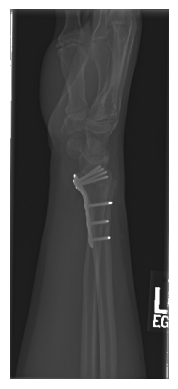

Image 7: Predicted: negative, True label: positive


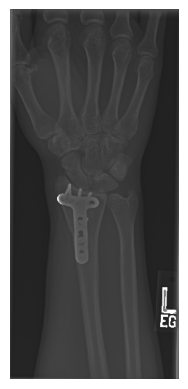

Image 8: Predicted: negative, True label: positive


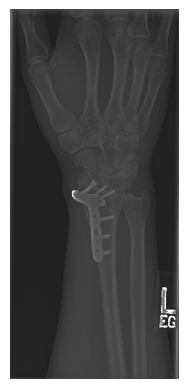

Image 9: Predicted: negative, True label: positive


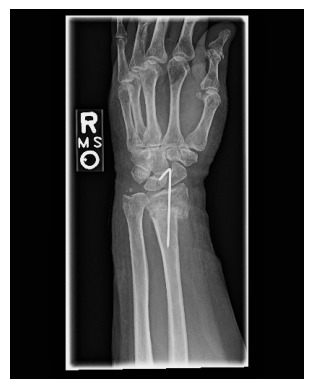

Image 10: Predicted: negative, True label: positive


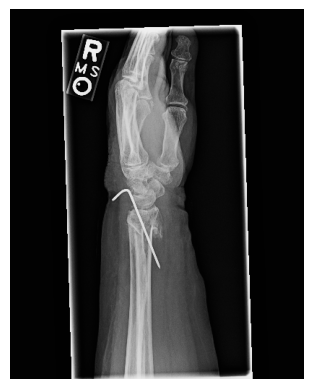

In [80]:
# Show the predictions and actual labels
for i, pred in enumerate(predictions):
    predicted_label = 'positive' if pred > 0.5 else 'negative'
    true_label = 'positive' if Y_test.iloc[i] == 1 else 'negative'
    
    print(f'Image {i+1}: Predicted: {predicted_label}, True label: {true_label}')
    load_and_show_image(valid_images_paths.iloc[i]["image_path"])